In [7]:
import numpy as np
import pandas as pd

In [5]:
def dist(vector1: list, vector2: list) -> float:
    """
    This method will calculate the euclidean distance between two data points.
    
    :param: 
        vector1 - numerical list
        vector2 - numerical list

    :returns:
       the distance betwen two vectors (float)
    """
    return np.linalg.norm(np.array(vector1) - np.array(vector2))

In [2]:
def edge_cluster(cluster, window):
    deviation = dist(cluster['mean'], window['mean']) > (dist(cluster['low'], cluster['mean']) + dist(window['mean'], window['high']))
            # D(m_i, m_w) > (D(l_i, m_i) + D(m_w, h_w))
    matching = (dist(cluster['mean'], window['mean']) < dist(cluster['low'], cluster['mean'])) and (dist(cluster['mean'], window['mean']) < dist(window['mean'], window['high']))
            # (D(m_i, m_w) < D(l_i, m_i)) and (D(m_i, m_w) < D(m_w, h_w))
    merging = (dist(cluster['low'], cluster['mean']) >= dist(cluster['mean'], window['mean'])) or (dist(cluster['mean'], window['mean']) <= dist(window['mean'], window['high']))
            # (D(l_i, m_i) >= D(m_i, m_w)) or (D(m_i, m_w) <= D(m_w, h_w))
            # merging c and w and recalculating the window - low, high, and mean vectors.
                
    new_cluster = (dist(cluster['low'], cluster['mean']) < dist(cluster['mean'], window['mean'])) and (dist(cluster['mean'], window['mean']) > dist(window['mean'], window['high']))
            # (D(l_i, m_i) < D(m_i, m_w)) and (D(m_i, m_w) > D(m_w, h_w))
    return deviation, matching, merging, new_cluster

Stream 0 segment 1 size 3

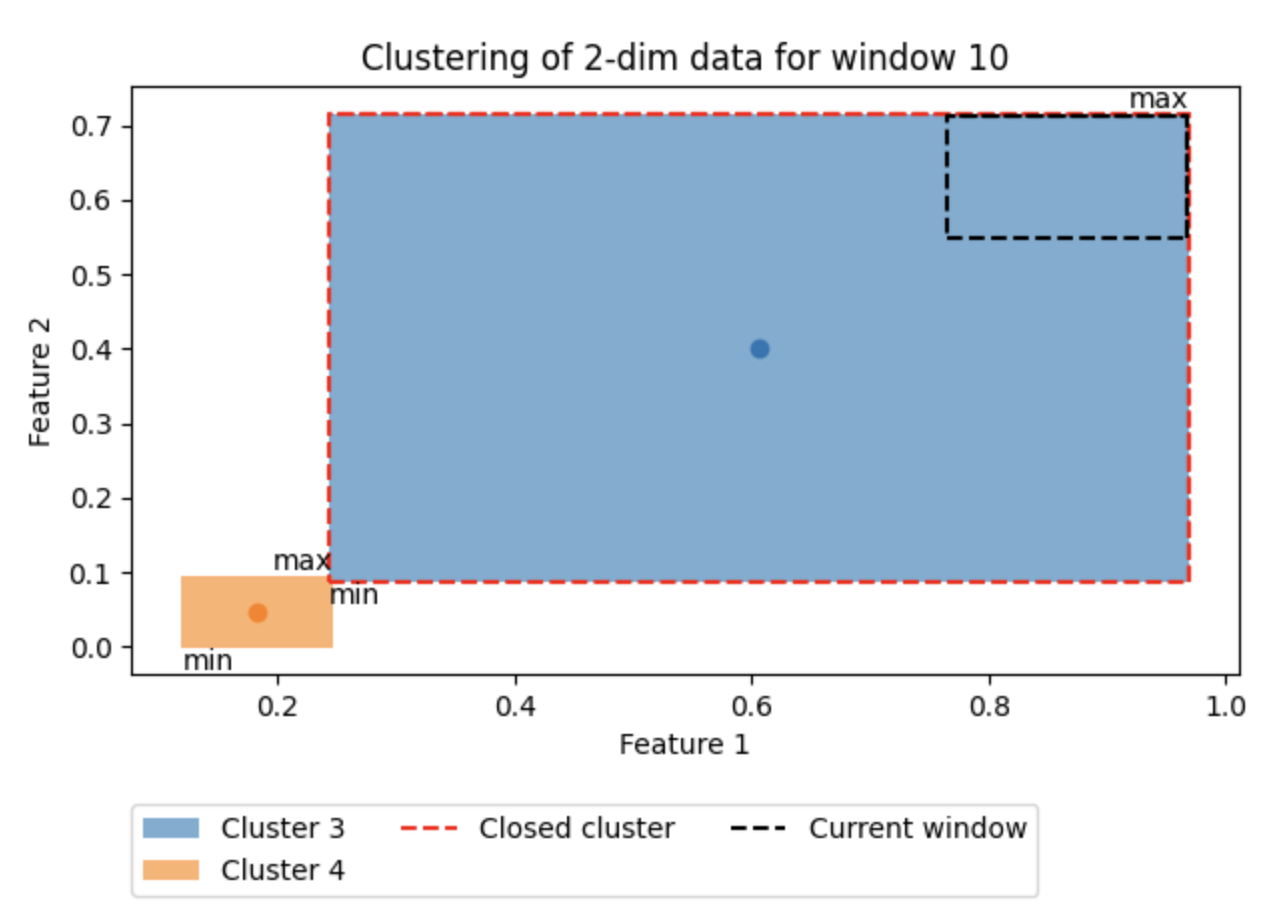

In [3]:
cluster = {
    "high": [0.81652366, 0.94245869],
    "mean": [0.72572486, 0.87937823],
    "low": [0.63492606, 0.81629777],
}

window = {
    "high": [0.72595944, 0.95704383],
    "mean": [0.65199986, 0.89350938],
    "low": [0.57804028, 0.82997494],
}


In [8]:
deviation, matching, merging, new_cluster = edge_cluster(cluster, window)

In [9]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching True
merging True
form a new cluster False


In [10]:
print(dist(cluster['mean'], window['mean']))
print(dist(cluster['low'], cluster['mean'])) 
print(dist(window['mean'], window['high']))

0.07506707017942359
0.11056023930532899
0.09750202977671238


In [31]:
def recalculate_window_params(c: dict, w: dict) -> dict:
    """
    Recalculating the window low, high value vectors of c.

    :param: c - a dict with keys: high, low, and mean.
    :param: w - a dict with keys: high, low, and mean.

    :returns: c - with new values for high, low and mean.
    """
    
    lows_df = pd.DataFrame([c['low'], w['low']])
    highs_df = pd.DataFrame([c['high'], w['high']])

    highs = highs_df.max()
    lows = lows_df.min()
    means = (highs + lows) / 2

    return {
        "high": np.array(highs), 
        "low": np.array(lows),
        "mean": np.array(means),
        "cluster": c['cluster'],
    }

In [32]:
j = {
    "high": [0.24717815, 0.09366411],
    "mean": [0.18308194, 0.04625368],
    "low": [ 0.11898573, -0.00115675],
    "cluster": 4
}

cluster = {
    "high": [0.96867268, 0.71623511],
    "mean": [0.60587082, 0.40125605],
    "low": [0.24306896, 0.08627698],
    "cluster": 3
}

window = {
    "high": [0.9666365,  0.71177258],
    "mean": [0.86542274, 0.63046239],
    "low": [0.76420898, 0.54915221]
}

cluster = recalculate_window_params(cluster, window)
print(cluster)
cluster['cluster'] != j['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean'])) or (dist(cluster['mean'], j['mean']) <= dist(j['mean'], j['high'])))

{'high': array([0.96867268, 0.71623511]), 'low': array([0.24306896, 0.08627698]), 'mean': array([0.60587082, 0.40125605]), 'cluster': 3}


False

In [33]:
print(dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean']))
print((dist(cluster['mean'], j['mean']) <= dist(j['mean'], j['high'])))

False
False


Stream 0 segment 1 size 5

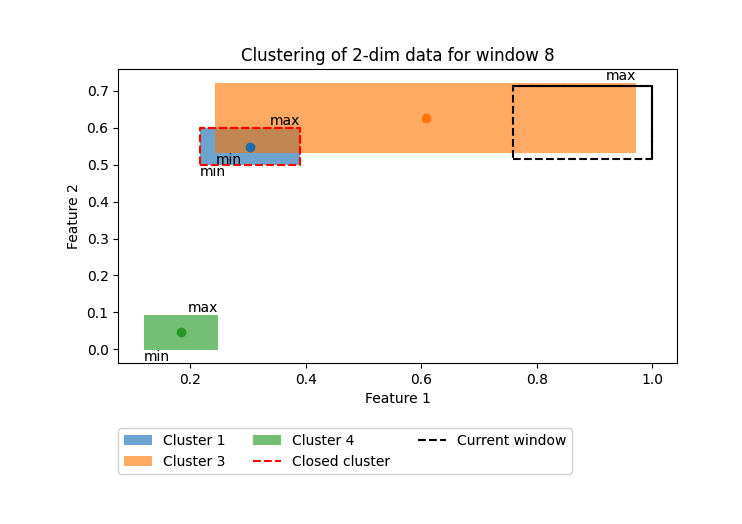

In [40]:
cluster = {
    "high": [0.39029833, 0.59833918],
    "mean": [0.30342303, 0.54862778],
    "low": [0.21654772, 0.49891637],
    "cluster": 1
}

window = {
    "high": [0.99891212, 0.71477947],
    "mean": [0.87901177, 0.61542624],
    "low": [0.75911142, 0.516073  ],
}

j = {
    "high": [0.97173226, 0.7224287 ],
    "mean": [0.60740061, 0.62736944],
    "low": [0.24306896, 0.53231018],
    "cluster": 3
}

k = {
    "high": [0.24717815, 0.09366411],
    "mean": [0.18308194, 0.04625368],
    "low": [ 0.11898573, -0.00115675],
    "cluster": 4
}

In [41]:
from sklearn.metrics import pairwise_distances_argmin
# print([np.ndarray([0.87901177, 0.61542624])])
clusters = np.array([[0.30342303, 0.54862778], [0.60740061, 0.62736944], [0.18308194, 0.04625368]])

print(pairwise_distances_argmin([np.array([0.87901177, 0.61542624])], clusters))

[1]


In [42]:
deviation, matching, merging, new_cluster = edge_cluster({
    "high": [0.97173226, 0.7224287 ],
    "mean": [0.60740061, 0.62736944],
    "low": [0.24306896, 0.53231018],
    "cluster": 3
}
, window)

# cluster = recalculate_window_params(cluster, window)
# print(cluster)

# cluster['cluster'] != j['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean'])) or (dist(cluster['mean'], j['high']) <= dist(j['mean'], j['high'])))
# cluster['cluster'] != k['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], k['mean'])) or (dist(cluster['mean'], k['high']) <= dist(k['mean'], k['high'])))

In [43]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching False
merging True
form a new cluster False


In [44]:
def find_the_closest_cluster(w: dict, C: list) -> dict:
    """
    Find the closest cluster to the window w.

    :param: w - a data window
    :param: C - list of Clusters

    :return: the closest cluster
    """
    results = []
    for c in C:
        results.append({
            "dist": dist(w['mean'], c['mean']),
            "cluster": c
        })
    sorted_results = sorted(results, key=lambda x: x['dist'], reverse=False)
    print(sorted_results)
    min_dist = None
    if len(sorted_results) != 0:
        min_dist = sorted_results[0]['cluster']
        sorted_results.append({
            "window": w,
            "cluster": c,
            "dist": min_dist
        })
    
    return min_dist

In [45]:

find_the_closest_cluster(window, [cluster, j, k])

[{'dist': 0.271873614502742, 'cluster': {'high': [0.97173226, 0.7224287], 'mean': [0.60740061, 0.62736944], 'low': [0.24306896, 0.53231018], 'cluster': 3}}, {'dist': 0.5794518374059738, 'cluster': {'high': [0.39029833, 0.59833918], 'mean': [0.30342303, 0.54862778], 'low': [0.21654772, 0.49891637], 'cluster': 1}}, {'dist': 0.8990415626325529, 'cluster': {'high': [0.24717815, 0.09366411], 'mean': [0.18308194, 0.04625368], 'low': [0.11898573, -0.00115675], 'cluster': 4}}]


{'high': [0.97173226, 0.7224287],
 'mean': [0.60740061, 0.62736944],
 'low': [0.24306896, 0.53231018],
 'cluster': 3}

In [102]:
c = {"high": [0.91108632, 0.47439582], "low": [0.77159713, 0.16752842], "mean": [0.84134172, 0.32096212]}
w = {"high": [0.94054342, 0.16020595], "low": [0.84728844, 0.06243238], "mean": [0.89391593, 0.11131916]}

c = {"high": [10,9], "low": [3,5], "mean": [6.5, 7]}
w = {"high": [14,6], "low": [9,2], "mean": [11.5, 4]}

c = {"high": [10,10], "low": [0,0], "mean": [5, 5]}
w = {"high": [15,15], "low": [5,5], "mean": [10, 10]}



In [147]:
# Define the np.array vectors of the top-right and bottom-left points of the rectangles
# rect1 = np.array([[10, 10], [0, 0]]) # Top-right: (10, 10), Bottom-left: (0, 0)
# rect2 = np.array([[15, 15], [5, 5]]) # Top-right: (15, 15), Bottom-left: (5, 5)

cluster = np.array([[0.55969858, 0.22157872], [0.46790469, 0.13344509]]) # cluster
window = np.array([[0.51900403, 0.16878762], [0.48262847, 0.06141023]]) # window

# Find the coordinates of the overlapping area using loops
left = []
right = []
bottom = []
top = []
# Loop over the dimensions of the vectors
for i in range(len(cluster[0])):
    # Append the max of the bottom-left coordinates to the left list
    left.append(np.max([cluster[1, i], window[1, i]]))
    # Append the min of the top-right coordinates to the right list
    right.append(np.min([cluster[0, i], window[0, i]]))
    # Append the max of the bottom-left coordinates to the bottom list
    bottom.append(np.max([cluster[1, i], window[1, i]]))
    # Append the min of the top-right coordinates to the top list
    top.append(np.min([cluster[0, i], window[0, i]]))
# Convert the lists to np.array vectors
left = np.array(left)
right = np.array(right)
bottom = np.array(bottom)
top = np.array(top)

# Check if the overlapping area is valid
if np.all(left < right) and np.all(bottom < top):
    # Print the coordinates of the overlapping area
    mean = ((cluster[0] + cluster[1]) / 2 + (window[0] + window[1]) / 2) / 2
    bottom = [np.max(cluster[1]), np.min(mean)]
    top = [np.max(cluster[0]), np.min(mean)]
    print(f"bottom: {cluster[1]}")
    print(f"top: {cluster[0]}")
    print(f"Mean: {mean}")
    print(f"Top-right: {top}")
    print(f"Bottom-left: {bottom}")
else:
    # Print a message if there is no overlapping area
    print("There is no overlapping area between the rectangles")

bottom: [0.46790469 0.13344509]
top: [0.55969858 0.22157872]
Mean: [0.50730894 0.14630541]
Top-right: [0.55969858, 0.146305415]
Bottom-left: [0.46790469, 0.146305415]
